# Deep Results Analysis

This notebook explores the generated analysis artifacts in `analysis/outputs/` and provides quick visual checks.

In [14]:
from pathlib import Path
import json
import pandas as pd

cwd = Path.cwd()
if (cwd / 'analysis' / 'outputs').exists():
    ROOT = cwd
elif (cwd / 'outputs').exists() and cwd.name == 'analysis':
    ROOT = cwd.parent
else:
    # Fallback for notebook executions from nested working directories
    candidates = [cwd, *cwd.parents]
    ROOT = next((p for p in candidates if (p / 'analysis' / 'outputs').exists()), cwd)

ANALYSIS_OUT = ROOT / 'analysis' / 'outputs'
assert ANALYSIS_OUT.exists(), f'Expected analysis outputs at: {ANALYSIS_OUT}'
ANALYSIS_OUT

WindowsPath('c:/Users/hugok/OneDrive/Dokumenty/GitHub/NLP_Final_project/analysis/outputs')

In [25]:
# Ensure plotting dependency is available in the current notebook kernel
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    %pip install -q matplotlib
    import matplotlib.pyplot as plt

print('matplotlib ready')

Note: you may need to restart the kernel to use updated packages.
matplotlib ready


In [15]:
summary = json.loads((ANALYSIS_OUT / 'analysis_summary.json').read_text(encoding='utf-8'))
summary

{'num_seed_rows': 25,
 'num_multiseed_rows': 8,
 'top_seed_by_macro_f1': {'experiment_name': 'bert_base_baseline',
  'summary_path': 'outputs/modeling/bert_base/logs/seed_43/run_summary.json',
  'seed': 43,
  'model_name': 'bert-base-uncased',
  'model_family': 'bert',
  'variant': 'original',
  'allowed_slang_labels': '',
  'test_accuracy': 0.9334964412811388,
  'test_macro_f1': 0.9263979824969478,
  'num_test_samples': 4496,
  'test_evaluated_from': 'best_model'},
 'top_multiseed_by_macro_f1': {'experiment_name': 'bert_base_baseline',
  'summary_path': 'outputs/modeling/bert_base/logs/multiseed/multiseed_summary.json',
  'config_path': 'configs/modeling/bert_base_baseline.yaml',
  'seeds': '42|43|44',
  'test_accuracy_mean': 0.9322360616844603,
  'test_accuracy_std': 0.0016394828282544464,
  'test_macro_f1_mean': 0.9248001643336989,
  'test_macro_f1_std': 0.002462044146834346,
  'num_test_samples': 4496},
 'bertweet_slang_masked_outlier': {'experiment': 'bertweet_slang_masked',
  'st

In [16]:
seed_df = pd.read_csv(ANALYSIS_OUT / 'seed_metrics_clean.csv')
multi_df = pd.read_csv(ANALYSIS_OUT / 'ranking_multiseed_macro_f1.csv')
slang_df = pd.read_csv(ANALYSIS_OUT / 'slang_heavy_subgroup_metrics.csv')
finetune_df = pd.read_csv(ANALYSIS_OUT / 'finetune_vs_baseline_slang_heavy.csv')

seed_df.head(), multi_df.head()

(      experiment_name                                       summary_path  \
 0  bert_base_baseline  outputs/modeling/bert_base/logs/seed_42/run_su...   
 1  bert_base_baseline  outputs/modeling/bert_base/logs/seed_43/run_su...   
 2  bert_base_baseline  outputs/modeling/bert_base/logs/seed_44/run_su...   
 3     bert_base_mixed  outputs/modeling/bert_base_mixed/logs/seed_42/...   
 4     bert_base_mixed  outputs/modeling/bert_base_mixed/logs/seed_43/...   
 
    seed         model_name model_family   variant allowed_slang_labels  \
 0    42  bert-base-uncased         bert  original                  NaN   
 1    43  bert-base-uncased         bert  original                  NaN   
 2    44  bert-base-uncased         bert  original                  NaN   
 3    42  bert-base-uncased         bert     mixed                  NaN   
 4    43  bert-base-uncased         bert     mixed                  NaN   
 
    test_accuracy  test_macro_f1  num_test_samples test_evaluated_from  
 0       0.

In [17]:
multi_df[['experiment_name', 'test_accuracy_mean', 'test_macro_f1_mean', 'test_macro_f1_std']].head(10)

,experiment_name,test_accuracy_mean,test_macro_f1_mean,test_macro_f1_std
0,bert_base_baseline,0.932236,0.924800,0.002462
1,bert_base_slang_masked,0.928381,0.921244,0.001877
2,bert_base_mixed,0.927639,0.920525,0.002749
3,bertweet_mixed,0.920374,0.911298,0.002150
4,bertweet_baseline,0.916444,0.909201,0.010386
5,bert_finetune_slang_heavy,0.896541,0.890926,0.000943
6,bert_finetune_slang_heavy_mixed,0.894092,0.888040,0.000504
7,bertweet_slang_masked,0.577254,0.431323,0.413349


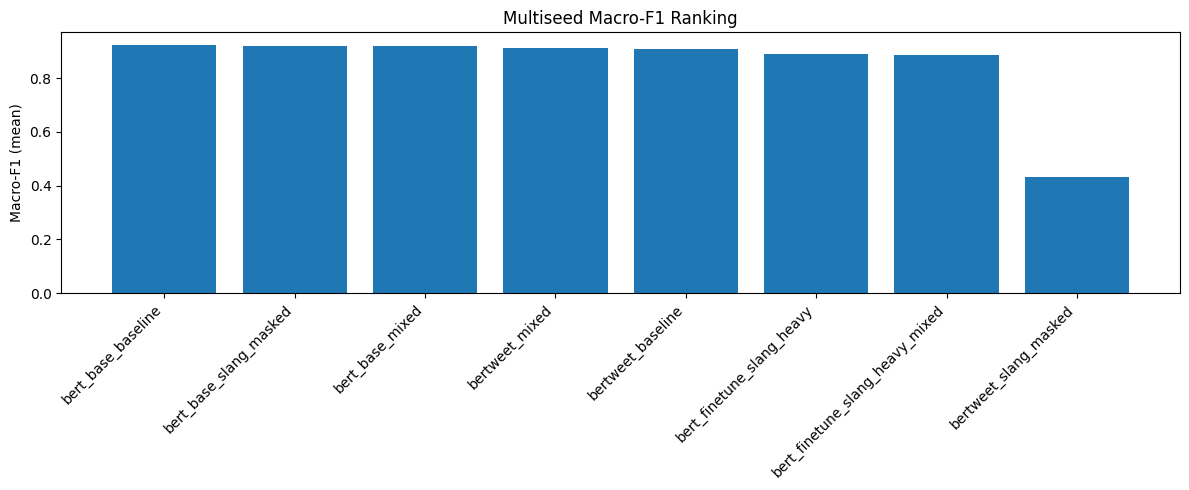

In [26]:
# Plotting setup with fallback when matplotlib is unavailable
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False
    print("matplotlib is not installed in this kernel. Run `%pip install matplotlib` to enable plots.")

plot_df = multi_df.copy().head(8)
if HAS_MPL:
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df['experiment_name'], plot_df['test_macro_f1_mean'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Macro-F1 (mean)')
    plt.title('Multiseed Macro-F1 Ranking')
    plt.tight_layout()
    plt.show()
else:
    plot_df[['experiment_name', 'test_macro_f1_mean', 'test_macro_f1_std']]

In [19]:
finetune_df

,comparison,baseline_slang_heavy_accuracy_mean,finetune_accuracy_mean,delta_accuracy_finetune_minus_baseline,baseline_slang_heavy_macro_f1_mean,finetune_macro_f1_mean,delta_macro_f1_finetune_minus_baseline
0,bert_base_baseline vs bert_finetune_slang_heavy,0.933578,0.896541,-0.037037,0.928472,0.890926,-0.037546
1,bert_base_mixed vs bert_finetune_slang_heavy_m...,0.924855,0.894092,-0.030762,0.919270,0.888040,-0.031229


## Extended Diagnostics

This section adds deeper diagnostics:
- seed-level stability and outlier detection
- uncertainty-aware multiseed ranking (mean +- std)
- subgroup-focused comparison for slang-heavy behavior
- baseline vs finetune delta visualization

In [20]:
import numpy as np
import pandas as pd

# Guard: load required dataframes if setup cells were not run in this kernel session
if 'ANALYSIS_OUT' not in globals():
    from pathlib import Path
    cwd = Path.cwd()
    if (cwd / 'analysis' / 'outputs').exists():
        ROOT = cwd
    elif (cwd / 'outputs').exists() and cwd.name == 'analysis':
        ROOT = cwd.parent
    else:
        candidates = [cwd, *cwd.parents]
        ROOT = next((p for p in candidates if (p / 'analysis' / 'outputs').exists()), cwd)
    ANALYSIS_OUT = ROOT / 'analysis' / 'outputs'

if 'seed_df' not in globals() or 'multi_df' not in globals() or 'slang_df' not in globals() or 'finetune_df' not in globals():
    seed_df = pd.read_csv(ANALYSIS_OUT / 'seed_metrics_clean.csv')
    multi_df = pd.read_csv(ANALYSIS_OUT / 'ranking_multiseed_macro_f1.csv')
    slang_df = pd.read_csv(ANALYSIS_OUT / 'slang_heavy_subgroup_metrics.csv')
    finetune_df = pd.read_csv(ANALYSIS_OUT / 'finetune_vs_baseline_slang_heavy.csv')

# Derive analysis-friendly columns
seed_df = seed_df.copy()
multi_df = multi_df.copy()

seed_df['family_variant'] = seed_df['model_family'] + ' | ' + seed_df['variant']
seed_df['is_finetune'] = seed_df['experiment_name'].str.contains('finetune')

multi_df['model_family'] = np.where(
    multi_df['experiment_name'].str.contains('bertweet'),
    'bertweet',
    np.where(multi_df['experiment_name'].str.contains('gpt'), 'gpt', 'bert')
)
multi_df['variant'] = np.select(
    [
        multi_df['experiment_name'].str.contains('slang_masked'),
        multi_df['experiment_name'].str.contains('mixed')
    ],
    ['slang_masked', 'mixed'],
    default='original'
)

seed_df[['experiment_name', 'seed', 'test_accuracy', 'test_macro_f1', 'family_variant']].head()

,experiment_name,seed,test_accuracy,test_macro_f1,family_variant
0,bert_base_baseline,42,0.932829,0.926038,bert | original
1,bert_base_baseline,43,0.933496,0.926398,bert | original
2,bert_base_baseline,44,0.930383,0.921965,bert | original
3,bert_base_mixed,42,0.925712,0.919202,bert | mixed
4,bert_base_mixed,43,0.925934,0.918687,bert | mixed


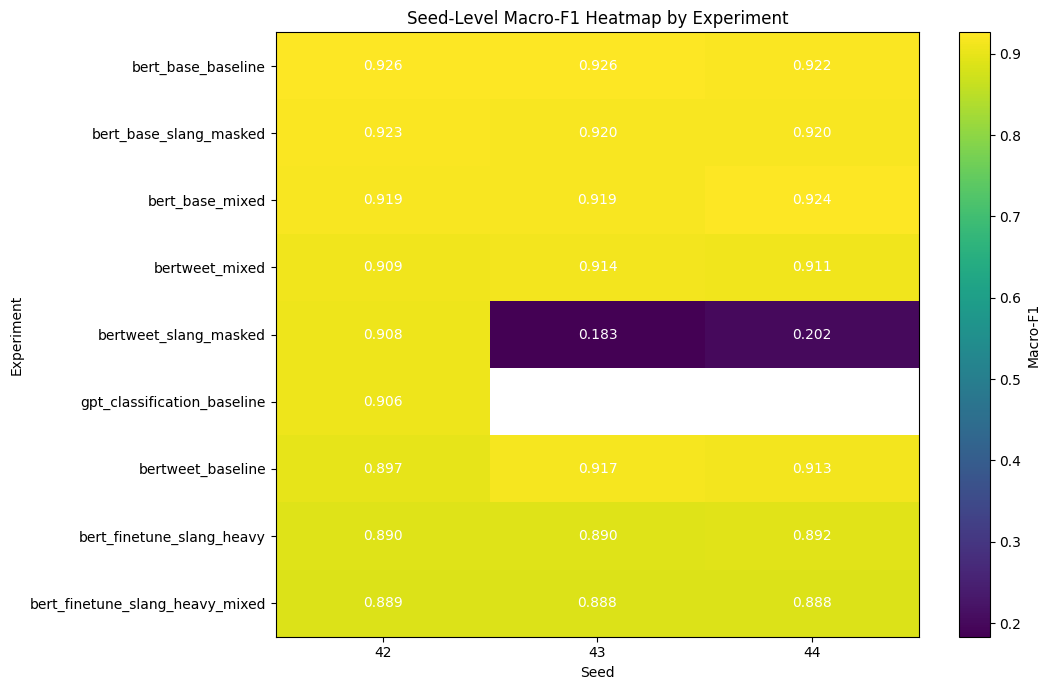

,experiment_name,seed_macro_f1_std
7,bertweet_slang_masked,0.413349
5,bertweet_baseline,0.010386
1,bert_base_mixed,0.002749
0,bert_base_baseline,0.002462
6,bertweet_mixed,0.002150
2,bert_base_slang_masked,0.001877
3,bert_finetune_slang_heavy,0.000943
4,bert_finetune_slang_heavy_mixed,0.000504


In [27]:
# 1) Seed-level stability heatmap (with fallback)
heat = seed_df.pivot_table(
    index='experiment_name',
    columns='seed',
    values='test_macro_f1',
    aggfunc='mean'
)
heat = heat.sort_values(by=42, ascending=False)

if globals().get('HAS_MPL', False):
    fig, ax = plt.subplots(figsize=(11, 7))
    im = ax.imshow(heat.values, aspect='auto')

    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([str(c) for c in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(list(heat.index))
    ax.set_xlabel('Seed')
    ax.set_ylabel('Experiment')
    ax.set_title('Seed-Level Macro-F1 Heatmap by Experiment')

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', color='white')

    fig.colorbar(im, ax=ax, label='Macro-F1')
    plt.tight_layout()
    plt.show()
else:
    heat

seed_std = seed_df.groupby('experiment_name', as_index=False)['test_macro_f1'].std().rename(columns={'test_macro_f1': 'seed_macro_f1_std'})
seed_std.sort_values('seed_macro_f1_std', ascending=False).head(8)

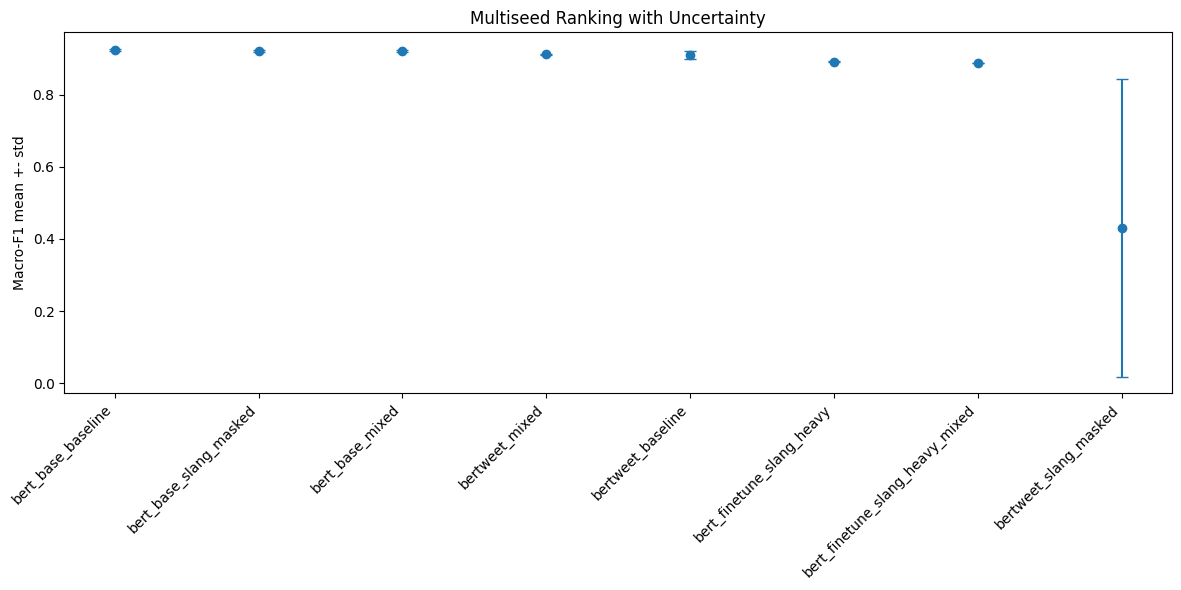

,experiment_name,test_accuracy_mean,test_macro_f1_mean,test_macro_f1_std
0,bert_base_baseline,0.932236,0.924800,0.002462
1,bert_base_slang_masked,0.928381,0.921244,0.001877
2,bert_base_mixed,0.927639,0.920525,0.002749
3,bertweet_mixed,0.920374,0.911298,0.002150
4,bertweet_baseline,0.916444,0.909201,0.010386
5,bert_finetune_slang_heavy,0.896541,0.890926,0.000943
6,bert_finetune_slang_heavy_mixed,0.894092,0.888040,0.000504
7,bertweet_slang_masked,0.577254,0.431323,0.413349


In [28]:
# 2) Multiseed ranking with uncertainty (mean +- std)
rank = multi_df.sort_values('test_macro_f1_mean', ascending=False).copy()

if globals().get('HAS_MPL', False):
    plt.figure(figsize=(12, 6))
    plt.errorbar(
        x=rank['experiment_name'],
        y=rank['test_macro_f1_mean'],
        yerr=rank['test_macro_f1_std'],
        fmt='o',
        capsize=4
    )
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Macro-F1 mean +- std')
    plt.title('Multiseed Ranking with Uncertainty')
    plt.tight_layout()
    plt.show()

rank[['experiment_name', 'test_accuracy_mean', 'test_macro_f1_mean', 'test_macro_f1_std']]

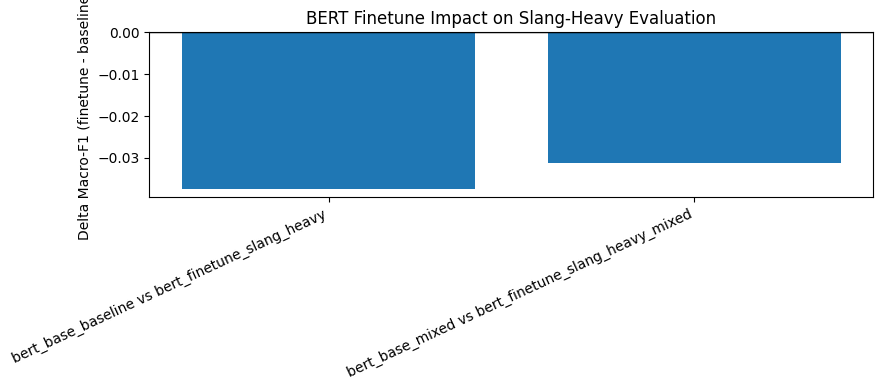

,comparison,delta_accuracy_finetune_minus_baseline,delta_macro_f1_finetune_minus_baseline
0,bert_base_baseline vs bert_finetune_slang_heavy,-0.037037,-0.037546
1,bert_base_mixed vs bert_finetune_slang_heavy_m...,-0.030762,-0.031229


In [29]:
# 3) Slang-heavy subgroup diagnostics and finetune delta chart
slang_group = slang_df.groupby('experiment_name', as_index=False).agg(
    slang_heavy_accuracy_mean=('slang_heavy_accuracy', 'mean'),
    slang_heavy_accuracy_std=('slang_heavy_accuracy', 'std'),
    slang_heavy_macro_f1_mean=('slang_heavy_macro_f1', 'mean'),
    slang_heavy_macro_f1_std=('slang_heavy_macro_f1', 'std'),
)

slang_group.sort_values('slang_heavy_macro_f1_mean', ascending=False).head(12)

fin = finetune_df.copy()
if globals().get('HAS_MPL', False):
    plt.figure(figsize=(9, 4))
    plt.axhline(0.0, color='black', linewidth=1)
    plt.bar(fin['comparison'], fin['delta_macro_f1_finetune_minus_baseline'])
    plt.xticks(rotation=25, ha='right')
    plt.ylabel('Delta Macro-F1 (finetune - baseline)')
    plt.title('BERT Finetune Impact on Slang-Heavy Evaluation')
    plt.tight_layout()
    plt.show()

fin[['comparison', 'delta_accuracy_finetune_minus_baseline', 'delta_macro_f1_finetune_minus_baseline']]

In [24]:
# 4) Quick anomaly detector: experiments with very high seed variance
anomaly = seed_df.groupby('experiment_name', as_index=False).agg(
    macro_f1_mean=('test_macro_f1', 'mean'),
    macro_f1_std=('test_macro_f1', 'std'),
    acc_mean=('test_accuracy', 'mean'),
    acc_std=('test_accuracy', 'std'),
    n=('seed', 'count')
).sort_values('macro_f1_std', ascending=False)

anomaly


,experiment_name,macro_f1_mean,macro_f1_std,acc_mean,acc_std,n
7,bertweet_slang_masked,0.431323,0.413349,0.577254,0.295806,3
5,bertweet_baseline,0.909201,0.010386,0.916444,0.010359,3
1,bert_base_mixed,0.920525,0.002749,0.927639,0.003148,3
0,bert_base_baseline,0.924800,0.002462,0.932236,0.001639,3
6,bertweet_mixed,0.911298,0.002150,0.920374,0.001353,3
2,bert_base_slang_masked,0.921244,0.001877,0.928381,0.002145,3
3,bert_finetune_slang_heavy,0.890926,0.000943,0.896541,0.001403,3
4,bert_finetune_slang_heavy_mixed,0.888040,0.000504,0.894092,0.000530,3
8,gpt_classification_baseline,0.906398,NaN,0.913701,NaN,1
